<a href="https://colab.research.google.com/github/Adityakumar626/fashion-mnist-optuna-hpo/blob/main/ann_fashion_mnist_pytorch_gpu_optimized_optuna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset , DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [36]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [37]:
# check for gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [38]:
df = pd.read_csv('fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [39]:
df.shape

(60000, 785)

<function matplotlib.pyplot.show(close=None, block=None)>

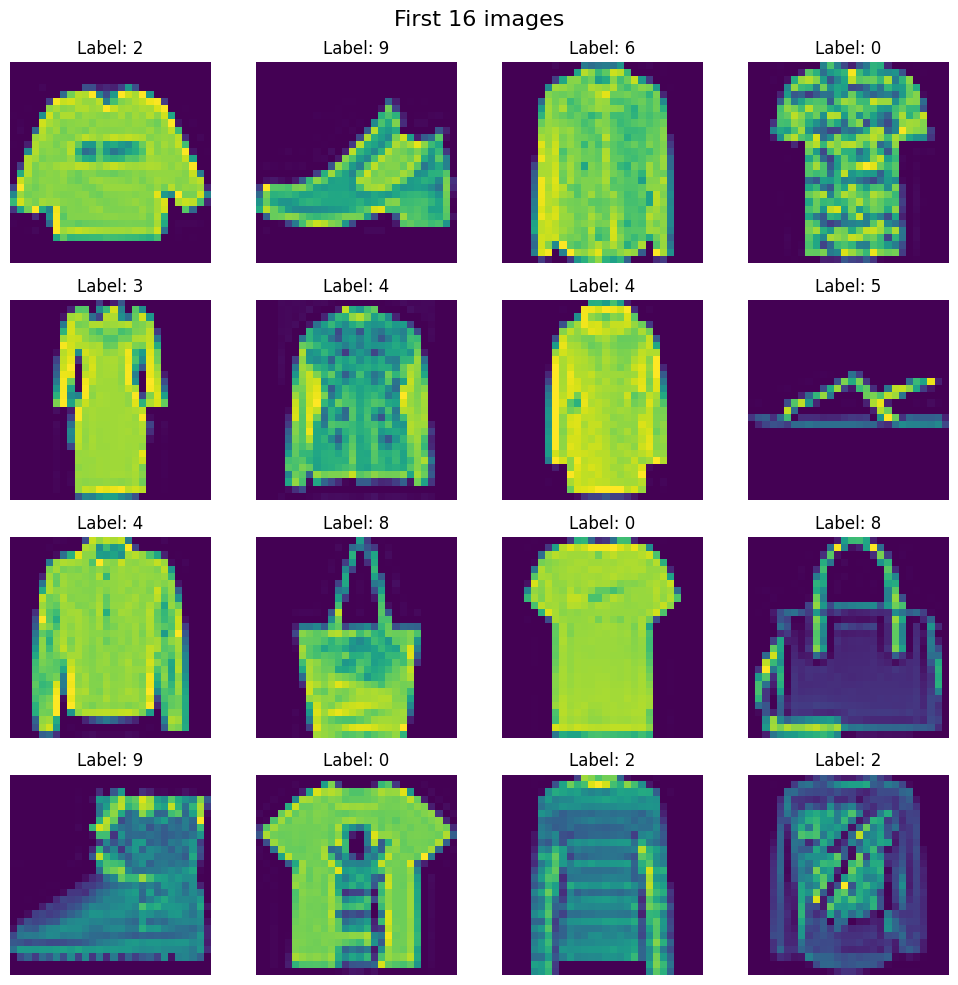

In [40]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 images" , fontsize = 16)

# Plot the first 16 images from dataset
for i , ax in enumerate(axes.flatten()):
    img = df.iloc[i , 1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label: {df.iloc[i , 0]}") # set the title

plt.tight_layout()
plt.show

In [41]:
x= df.iloc[:,1:].values
y= df.iloc[:,0].values

In [42]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 1:], df.iloc[:, 0], test_size=0.2,random_state=42)

In [43]:
# scaling the features
X_train = X_train / 255.0
X_test = X_test / 255.0

In [10]:
X_train

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
48572,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
38696,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
13611,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
35213,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
31766,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.003922,0.0,...,0.000000,0.000000,0.003922,0.000000,0.043137,0.145098,0.023529,0.000000,0.00000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54343,0.0,0.0,0.0,0.0,0.0,0.011765,0.027451,0.000000,0.000000,0.0,...,0.682353,0.705882,0.768627,0.921569,0.000000,0.000000,1.000000,0.898039,0.65098,0.0
38158,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
860,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.003922,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
15795,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.007843,0.000000,0.0,...,0.368627,0.290196,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.0


In [44]:
#  create custom dataset class
class CustomDataset(Dataset):

    def __init__(self, x, y):
        self.x = torch.tensor(x.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.long)


    def __len__(self):
      return len(self.x)

    def __getitem__(self, idx):
      return self.x[idx], self.y[idx]

In [45]:
# create train_dataset object
train_dataset = CustomDataset(X_train, y_train)

In [46]:
# create test_dataset object
test_dataset = CustomDataset(X_test, y_test)

In [47]:
class myNN(nn.Module):

  def __init__(self , input_dim ,  output_dim, num_hidden_layers, neurons_per_layer, dropout_rate):

    super().__init__()

    layers = []

    for i in range(num_hidden_layers):

      layers.append(nn.Linear(input_dim , neurons_per_layer)) # adding no. of hidden layers in it
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout_rate))
      input_dim = neurons_per_layer

    layers.append(nn.Linear(neurons_per_layer , output_dim))


    self.model = nn.Sequential(*layers)

  def forward(self , x):
    return self.model(x)

In [54]:
# objective function
def objective(trail) :

  # next hyperparameter values from the search space
    num_hidden_layers = trail.suggest_int("num_hidden_layers" , 1, 5)
    neurons_per_layer = trail.suggest_int("neurons_per_layer" , 8 , 128 , step=8)
    epochs = trail.suggest_int("epochs" , 10 ,50, step =10)
    learning_rate = trail.suggest_float("learning_rate" , 1e-5 , 1e-1 , log = True)
    dropout_rate = trail.suggest_float("dropout_rate" , 0.1 , 0.5 , step = 0.1)
    batch_size = trail.suggest_categorical("batch_size" , [16, 32 , 64 , 128])
    optimizer_name = trail.suggest_categorical("optimizer" , ["Adam" , "SGD", "RMSprop"])
    weight_decay = trail.suggest_float("weight_decay" , 1e-5 , 1e-3 , log = True)


  # create train and test loader
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True , pin_memory = True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False , pin_memory = True)

  # model init
    input_dim = 784
    output_dim = 10

    model = myNN(input_dim , output_dim , num_hidden_layers , neurons_per_layer, dropout_rate)
    model.to(device)

  # params init
    learning_rate = 0.1
    epochs = 50

  # optimizer selection
    criterion = nn.CrossEntropyLoss() #loss function
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4) #optimizer

    if optimizer_name == "Adam":
        optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    else :
      optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

  # training loop
    for epoch in range(epochs):

      for batch_features , batch_labels in train_loader:

        # move data to gpu
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        # forward pass
        outputs = model(batch_features)

        # calculate loss
        loss = criterion(outputs , batch_labels)

        # back props
        optimizer.zero_grad()
        loss.backward()

        # update the grads
        optimizer.step()

  # evaluation
    model.eval()

    total =0
    correct = 0

    with torch.no_grad():

      for batch_features , batch_labels in test_loader:

        # move data to gpu
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        outputs = model(batch_features)

        _, predeicted = torch.max(outputs,1)

        total += batch_labels.size(0)

        correct += (predeicted == batch_labels).sum().item()

      accuracy = correct / total

    return accuracy

In [15]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 18.4 MB/s eta 0:00:00


In [56]:
import optuna

study = optuna.create_study(direction = 'maximize')

[I 2026-09-28 19:50:37,792] A new study created in memory with name: no-name-4f3d8b64-c8a8-4120-adac-e3ee6a06ba9a


In [57]:
study.optimize(objective, n_trials = 10)

[I 2026-09-28 19:52:13,866] Trial 0 finished with value: 0.8624166666666667 and parameters: {'num_hidden_layers': 2, 'neurons_per_layer': 32, 'epochs': 30, 'learning_rate': 0.04821679085141864, 'dropout_rate': 0.30000000000000004, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.00014909134885369746}. Best is trial 0 with value: 0.8624166666666667.
[I 2026-09-28 19:58:13,274] Trial 1 finished with value: 0.8401666666666666 and parameters: {'num_hidden_layers': 2, 'neurons_per_layer': 24, 'epochs': 50, 'learning_rate': 0.007627351958871425, 'dropout_rate': 0.30000000000000004, 'batch_size': 16, 'optimizer': 'SGD', 'weight_decay': 0.0004640812983133374}. Best is trial 0 with value: 0.8624166666666667.
[I 2026-09-28 20:00:37,995] Trial 2 finished with value: 0.8883333333333333 and parameters: {'num_hidden_layers': 3, 'neurons_per_layer': 120, 'epochs': 30, 'learning_rate': 0.0005413087607708297, 'dropout_rate': 0.4, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 2.72729737

In [58]:
for trial in study.trials:
    print(
        trial.number,
        trial.value,
        trial.params
    )

0 0.8624166666666667 {'num_hidden_layers': 2, 'neurons_per_layer': 32, 'epochs': 30, 'learning_rate': 0.04821679085141864, 'dropout_rate': 0.30000000000000004, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.00014909134885369746}
1 0.8401666666666666 {'num_hidden_layers': 2, 'neurons_per_layer': 24, 'epochs': 50, 'learning_rate': 0.007627351958871425, 'dropout_rate': 0.30000000000000004, 'batch_size': 16, 'optimizer': 'SGD', 'weight_decay': 0.0004640812983133374}
2 0.8883333333333333 {'num_hidden_layers': 3, 'neurons_per_layer': 120, 'epochs': 30, 'learning_rate': 0.0005413087607708297, 'dropout_rate': 0.4, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 2.7272973799311247e-05}
3 0.8878333333333334 {'num_hidden_layers': 1, 'neurons_per_layer': 120, 'epochs': 20, 'learning_rate': 0.007554092819712782, 'dropout_rate': 0.30000000000000004, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 2.358067743551291e-05}
4 0.8815 {'num_hidden_layers': 1, 'neurons_per_layer': 56

In [59]:
study.best_value

0.8975833333333333

In [60]:
study.best_params

{'num_hidden_layers': 4,
 'neurons_per_layer': 128,
 'epochs': 40,
 'learning_rate': 2.561811100321608e-05,
 'dropout_rate': 0.1,
 'batch_size': 64,
 'optimizer': 'Adam',
 'weight_decay': 0.00023415163953858178}